In [1]:
from PIL import Image
import numpy as np
import pandas as pd
from calibration import lifetime_to_temperature_water, lifetime_to_temperature_extract
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
cell_place = np.array(Image.open('./cell_roi256/cell02.tif'))
mito_image = np.array(Image.open('./mt_roi256/cell02.tif'))
cell_lifetime = np.array(Image.open('./Project_cell02_fast_256/Project_cell02_fast_256_ch01.tif'))/1000

26.740414200628038
25.45256910266741
1.287845097960627


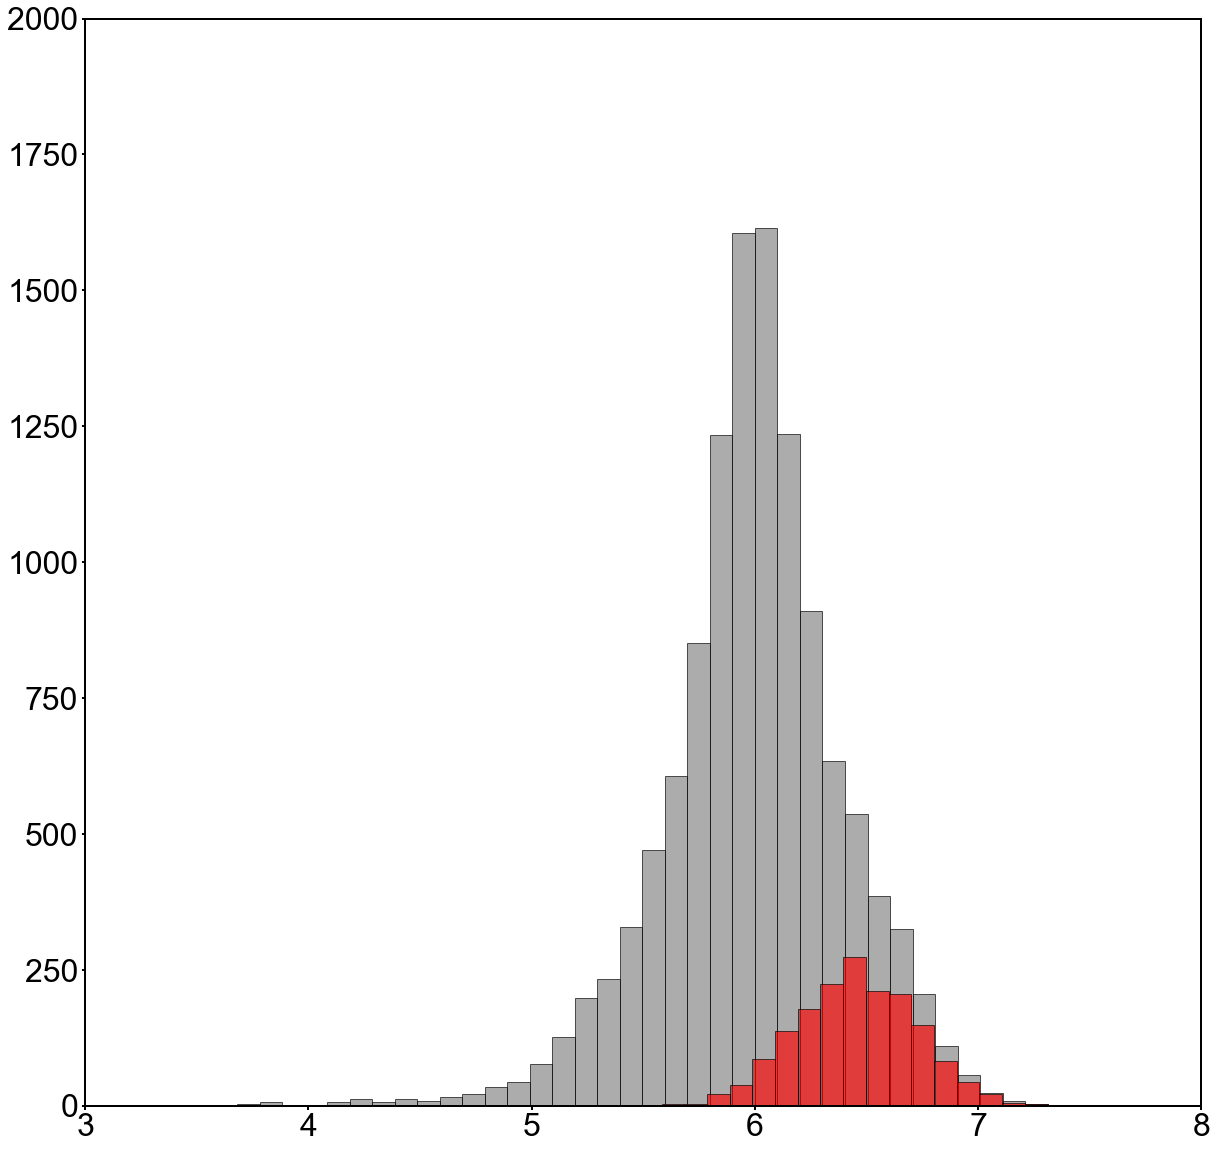

In [3]:
#体裁調節
fig = plt.figure(figsize = (20, 20))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
plt.tick_params(labelsize=32)

analyzed_area = np.where((cell_place == 20000), 1, 0) 
mito_area = np.where((mito_image == 255), 1, 0)

# 細胞質の形を抽出 
cyto_plasm_lifetime = analyzed_area*cell_lifetime
cyto_plasm_lifetime = cyto_plasm_lifetime[np.where(cyto_plasm_lifetime > 0)]
mito_lifetime = analyzed_area*mito_area*cell_lifetime
mito_lifetime = mito_lifetime[np.where(mito_lifetime > 0)]

#ビンを決める
mt_bins = int((max(mito_lifetime) - min(mito_lifetime))/0.1)
cyto_bins = int((max(cyto_plasm_lifetime) - min(cyto_plasm_lifetime))/0.1)


#平均温度の計算
mt_tmp = lifetime_to_temperature_extract(np.mean(mito_lifetime))
cyto_tmp = lifetime_to_temperature_extract(np.mean(cyto_plasm_lifetime))
dif = mt_tmp - cyto_tmp
print(mt_tmp)
print(cyto_tmp)
print(dif)

plt.hist(np.ravel(cyto_plasm_lifetime), bins = cyto_bins ,color = 'gray', ec = 'black', alpha = 0.65)
plt.hist(np.ravel(mito_lifetime), bins = mt_bins, color = 'red', ec = 'black', alpha = 0.65)
plt.xlim(3, 8)
plt.ylim(0, 2000)
plt.show()

#pdfのセーブ
pp = PdfPages('./fig1h.pdf')
pp.savefig(fig)
pp.close()

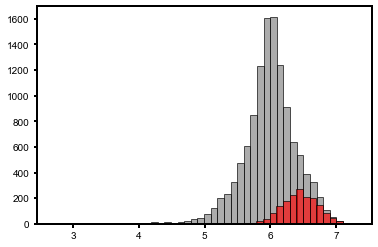

In [12]:
pd.DataFrame(plt.hist((np.ravel(cyto_plasm_lifetime)), bins = cyto_bins ,color = 'gray', ec = 'black', alpha = 0.65)).to_csv('cyto_hist.csv')
pd.DataFrame(plt.hist((np.ravel(mito_lifetime)), bins = mt_bins, color = 'red', ec = 'black', alpha = 0.65)).to_csv('mito_hist.csv')